In [1]:
import pandas as pd
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path().resolve().parents[0]))

from src.data_loader import load_train_data

train = load_train_data()

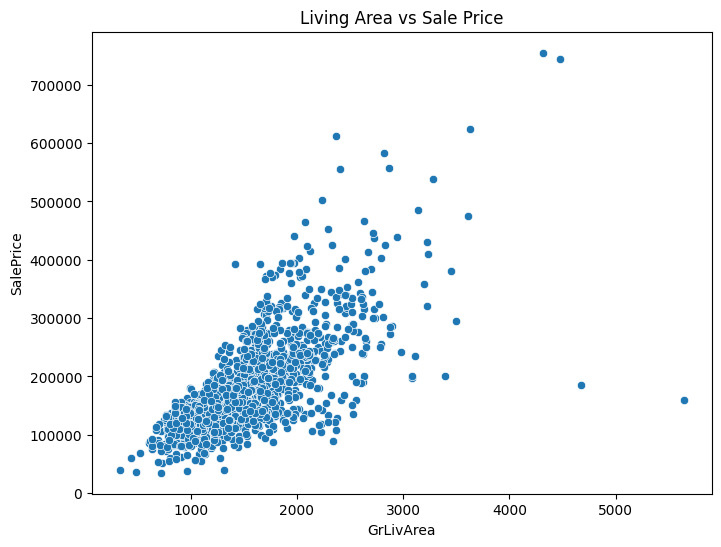

In [2]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"]
)

plt.title("Living Area vs Sale Price")
plt.show()

In [3]:
train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


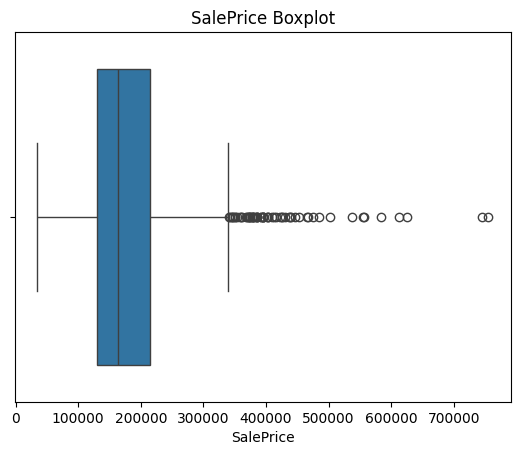

In [4]:
plt.figure()

sns.boxplot(x=train["SalePrice"])

plt.title("SalePrice Boxplot")
plt.show()

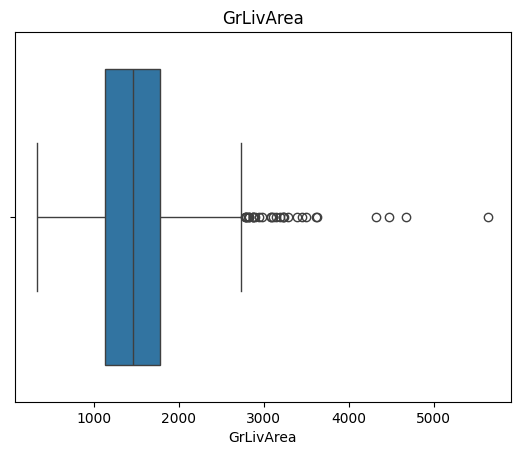

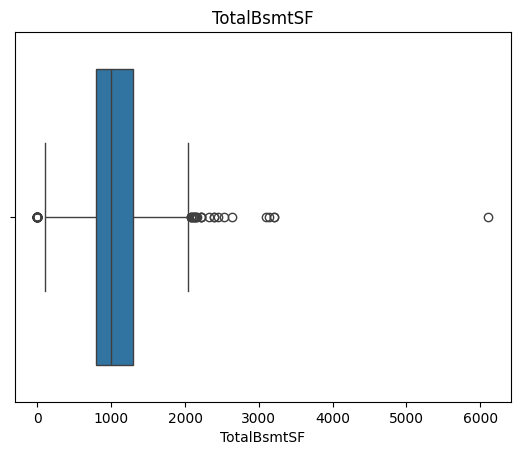

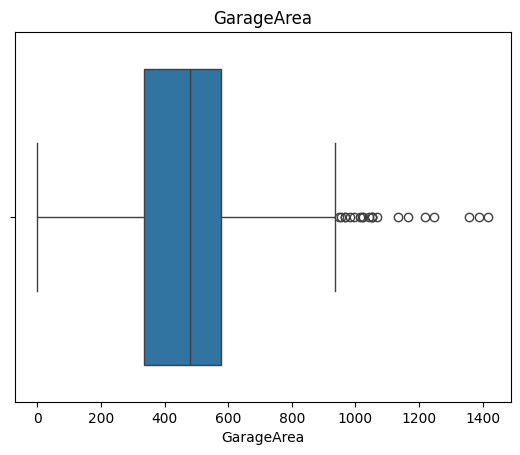

In [5]:
features = ["GrLivArea", "TotalBsmtSF", "GarageArea"]

for feature in features:
    
    plt.figure()
    sns.boxplot(x=train[feature])
    plt.title(feature)

In [6]:
Q1 = train["SalePrice"].quantile(0.25)
Q3 = train["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[
    (train["SalePrice"] < lower_bound) |
    (train["SalePrice"] > upper_bound)
]

outliers.shape

(61, 81)

In [7]:
train = train[train["GrLivArea"] < 4000]

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

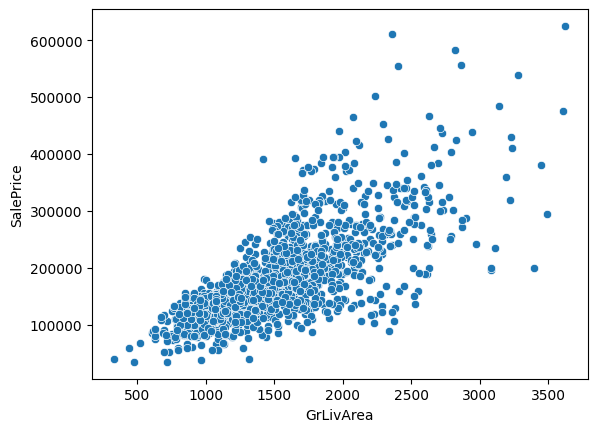

In [9]:
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])

Outlier Analysis

- Two extreme outliers were detected in the relationship between GrLivArea and SalePrice
- These observations correspond to unusually large houses sold at relatively low prices
- These points distort the linear relationship
- Following common practice for this dataset, observations with GrLivArea > 4000 were removed